# 🧠 Neroes Adaptive Neurofeedback - Exploratory Data Analysis

**Challenge:** Build a compact prototype that answers:
> *"Given the current physiological state and task context, what should the system do next to improve the target outcome in the next step or time window?"*

**Target variable:** `ProtocolValue` (to maximise)

**This notebook covers:**
1. Data loading & structural inspection (JSONs + CSVs)
2. Schema discovery - what signals do we have?
3. Temporal structure & subsession breakdown
4. Target variable (`ProtocolValue`) deep-dive
5. Behavioural signal (`PlayerPositionY`) analysis
6. Feature correlation & co-movement
7. Baseline (subsession 0) vs. game sessions (subsessions 1–9)
8. Key findings & modelling implications

---
> **Note on AI usage:** Claude (Anthropic) was used to scaffold this notebook structure and suggest analytical angles. All data interpretation, modelling decisions, and critical reflections are the author's own.

## 0. Setup & Configuration

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR = Path('../data/raw/NeroesSession_Data')
SUBSESSIONS_DIR = BASE_DIR / 'SubSessions'
SESSION_INFO_PATH = BASE_DIR / 'SessionInfo.json'

# ── Plot style ─────────────────────────────────────────────────────────────
NEROES_PALETTE = {
    'bg':       '#0d1117',
    'surface':  '#161b22',
    'cyan':     '#00c8ff',
    'teal':     '#00e5c3',
    'orange':   '#ff6b35',
    'yellow':   '#ffd700',
    'muted':    '#8b949e',
    'white':    '#e6edf3',
}

plt.rcParams.update({
    'figure.facecolor':  NEROES_PALETTE['bg'],
    'axes.facecolor':    NEROES_PALETTE['surface'],
    'axes.edgecolor':    NEROES_PALETTE['muted'],
    'axes.labelcolor':   NEROES_PALETTE['white'],
    'xtick.color':       NEROES_PALETTE['muted'],
    'ytick.color':       NEROES_PALETTE['muted'],
    'text.color':        NEROES_PALETTE['white'],
    'grid.color':        '#21262d',
    'grid.linestyle':    '--',
    'grid.linewidth':    0.5,
    'font.family':       'monospace',
    'axes.titlesize':    13,
    'axes.labelsize':    11,
})

SUBSESSION_COLORS = [NEROES_PALETTE['cyan']] + [
    plt.cm.plasma(i / 9) for i in range(9)
]

print('✅ Setup complete.')
print(f'   Base directory: {BASE_DIR.resolve()}')
print(f'   SubSessions found: {len(list(SUBSESSIONS_DIR.iterdir()))}')

✅ Setup complete.
   Base directory: /home/bruno1008/neroes/neroes-neurofeedback/data/raw/NeroesSession_Data
   SubSessions found: 10


## 1. Session-Level Metadata

In [2]:
# ── Load top-level SessionInfo ──────────────────────────────────────────────
with open(SESSION_INFO_PATH, 'r') as f:
    session_info = json.load(f)

print('═' * 60)
print('  SESSION INFO')
print('═' * 60)
print(json.dumps(session_info, indent=2, ensure_ascii=False))

════════════════════════════════════════════════════════════
  SESSION INFO
════════════════════════════════════════════════════════════
{
  "AsteroidCount": 14,
  "DistortedVisionCount": 0,
  "BlackHoleCount": 0,
  "RecoveryCount": 0,
  "RecoveryTotalTime": "00:00:00",
  "AccountId": "6873230ff3b644f4a071584bda4de5e7",
  "SessionId": "ecb82d82a5544973b4ad136ecea6051d",
  "OrganizationId": null,
  "TeamId": null,
  "ExperimentId": null,
  "GroupId": null,
  "Variant": "spaceship",
  "SessionNumber": 66,
  "Timestamp": "2025-10-23T13:31:48",
  "UploadTimestamp": "2025-10-23T14:02:10",
  "MiddlePercentileAverage": 0.0,
  "MiddlePercentileStandardDeviation": 0.0,
  "MiddleBaselineAverage": 0.0,
  "MiddleBaselineStandardDeviation": 0.0,
  "MiddleBaselineMin": 0.0,
  "MiddleBaselineMax": 0.0,
  "BaselineAverage": 0.0,
  "PerformanceRatingAverage": 0.0,
  "PerformanceRating": 0.0,
  "Score": 7.4356,
  "AboveBaselinePercentage": 0.0,
  "MoraleEnd": 0.0,
  "MoraleAverage": 0.0,
  "MoraleLost":

## 2. SubSession Metadata Inspection

In [3]:
# ── Load all SubSession Info.json files ─────────────────────────────────────
subsession_infos = {}

for ss_dir in sorted(SUBSESSIONS_DIR.iterdir(), key=lambda x: int(x.name)):
    ss_id = int(ss_dir.name)
    info_path = ss_dir / 'Info.json'
    if info_path.exists():
        with open(info_path, 'r') as f:
            subsession_infos[ss_id] = json.load(f)

print(f'Loaded Info.json for {len(subsession_infos)} subsessions\n')
print('═' * 60)
print('  SUBSESSION 0 (Baseline / Calibration):')
print('═' * 60)
print(json.dumps(subsession_infos.get(0, {}), indent=2, ensure_ascii=False))

print()
print('═' * 60)
print('  SUBSESSION 1 (First Game Session):')
print('═' * 60)
print(json.dumps(subsession_infos.get(1, {}), indent=2, ensure_ascii=False))

Loaded Info.json for 10 subsessions

════════════════════════════════════════════════════════════
  SUBSESSION 0 (Baseline / Calibration):
════════════════════════════════════════════════════════════
{
  "AsteroidCount": 0,
  "DistortedVisionCount": 0,
  "BlackHoleCount": 0,
  "RecoveryCount": 0,
  "RecoveryTotalTime": "00:00:00",
  "AccountId": "6873230ff3b644f4a071584bda4de5e7",
  "SessionId": "ecb82d82a5544973b4ad136ecea6051d",
  "Index": 0,
  "Timestamp": "2025-10-23T13:31:48",
  "UploadTimestamp": "2025-10-23T14:02:11",
  "MinBaseline": 0.0,
  "MiddleBaseline": 0.0,
  "MaxBaseline": 0.0,
  "TangentCoefficient": 0.0,
  "TranslationCoefficient": 0.0,
  "PercentileAverage": 0.0,
  "PercentileStandardDeviation": 0.0,
  "BaselineAverage": 0.0,
  "BaselineStandardDeviation": 0.0,
  "PerformanceRating": 0.0,
  "Score": 6.5,
  "AboveBaselinePercentage": 0.0,
  "MoraleEnd": 0.0,
  "MoraleAverage": 0.0,
  "MoraleLost": 0.0,
  "MoraleGained": 0.0,
  "ProtocolAverageToMaxRatio": 0.0,
  "Proto

In [4]:
# ── Summary table of all subsession metadata ────────────────────────────────
meta_rows = []
for ss_id, info in subsession_infos.items():
    row = {'subsession': ss_id}
    row.update({k: v for k, v in info.items() if not isinstance(v, (dict, list))})
    meta_rows.append(row)

meta_df = pd.DataFrame(meta_rows).set_index('subsession').sort_index()
print('SubSession Metadata Summary:')
display(meta_df)

SubSession Metadata Summary:


,AsteroidCount,DistortedVisionCount,BlackHoleCount,RecoveryCount,RecoveryTotalTime,AccountId,SessionId,Index,Timestamp,UploadTimestamp,...,T7SignalQuality,P7SignalQuality,O1SignalQuality,O2SignalQuality,P8SignalQuality,T8SignalQuality,FC6SignalQuality,F8SignalQuality,C3SignalQuality,C4SignalQuality
subsession,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,00:00:00,6873230ff3b644f4a071584bda4de5e7,ecb82d82a5544973b4ad136ecea6051d,0,2025-10-23T13:31:48,2025-10-23T14:02:11,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.9642,0.965394
1,0,0,0,0,00:00:00,6873230ff3b644f4a071584bda4de5e7,ecb82d82a5544973b4ad136ecea6051d,1,2025-10-23T13:38:51,2025-10-23T14:02:11,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0000,1.000000
2,1,0,0,0,00:00:00,6873230ff3b644f4a071584bda4de5e7,ecb82d82a5544973b4ad136ecea6051d,2,2025-10-23T13:40:53,2025-10-23T14:02:12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0000,1.000000
3,0,0,0,0,00:00:00,6873230ff3b644f4a071584bda4de5e7,ecb82d82a5544973b4ad136ecea6051d,3,2025-10-23T13:44:31,2025-10-23T14:02:12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0000,1.000000
4,1,0,0,0,00:00:00,6873230ff3b644f4a071584bda4de5e7,ecb82d82a5544973b4ad136ecea6051d,4,2025-10-23T13:46:47,2025-10-23T14:02:12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0000,1.000000
5,3,0,0,0,00:00:00,6873230ff3b644f4a071584bda4de5e7,ecb82d82a5544973b4ad136ecea6051d,5,2025-10-23T13:49:27,2025-10-23T14:02:13,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0000,1.000000
6,0,0,0,0,00:00:00,6873230ff3b644f4a071584bda4de5e7,ecb82d82a5544973b4ad136ecea6051d,6,2025-10-23T13:52:19,2025-10-23T14:02:13,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0000,1.000000
7,0,0,0,0,00:00:00,6873230ff3b644f4a071584bda4de5e7,ecb82d82a5544973b4ad136ecea6051d,7,2025-10-23T13:54:56,2025-10-23T14:02:14,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0000,1.000000
8,9,0,0,0,00:00:00,6873230ff3b644f4a071584bda4de5e7,ecb82d82a5544973b4ad136ecea6051d,8,2025-10-23T13:57:12,2025-10-23T14:02:14,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0000,1.000000


## 3. Data Loading - CSVs

In [5]:
# ── Load all Data.csv files ──────────────────────────────────────────────────
raw_dfs = {}

for ss_dir in sorted(SUBSESSIONS_DIR.iterdir(), key=lambda x: int(x.name)):
    ss_id = int(ss_dir.name)
    csv_path = ss_dir / 'Data.csv'
    if csv_path.exists():
        df = pd.read_csv(csv_path, skiprows=8)
        df['subsession'] = ss_id
        raw_dfs[ss_id] = df
        print(f'  SubSession {ss_id}: {df.shape[0]:>6,} rows × {df.shape[1]} cols')

print(f'\nTotal subsessions loaded: {len(raw_dfs)}')

  SubSession 0:    837 rows × 150 cols
  SubSession 1:    240 rows × 150 cols
  SubSession 2:    418 rows × 150 cols
  SubSession 3:    270 rows × 150 cols
  SubSession 4:    317 rows × 150 cols
  SubSession 5:    341 rows × 150 cols
  SubSession 6:    314 rows × 150 cols
  SubSession 7:    270 rows × 150 cols
  SubSession 8:    272 rows × 150 cols
  SubSession 9:    270 rows × 150 cols

Total subsessions loaded: 10


## 4. Schema Discovery

In [ ]:
# ── Inspect columns across all subsessions ───────────────────────────────────
print('═' * 70)
print('  COLUMN SCHEMA - SubSession 0 (Baseline)')
print('═' * 70)
ss0 = raw_dfs[0]
schema_df = pd.DataFrame({
    'dtype':    ss0.dtypes,
    'non_null': ss0.notna().sum(),
    'null_%':   (ss0.isna().mean() * 100).round(2),
    'sample':   ss0.iloc[0],
})
display(schema_df)

print()
print('═' * 70)
print('  COLUMN SCHEMA - SubSession 1 (Game)')
print('═' * 70)
ss1 = raw_dfs[1]
schema_df1 = pd.DataFrame({
    'dtype':    ss1.dtypes,
    'non_null': ss1.notna().sum(),
    'null_%':   (ss1.isna().mean() * 100).round(2),
    'sample':   ss1.iloc[0],
})
display(schema_df1)

══════════════════════════════════════════════════════════════════════
  COLUMN SCHEMA — SubSession 0 (Baseline)
══════════════════════════════════════════════════════════════════════


,dtype,non_null,null_%,sample
AF3Alpha,int64,837,0.0,0
AF3Gamma,int64,837,0.0,0
AF3HighBeta,int64,837,0.0,0
AF3LowBeta,int64,837,0.0,0
AF3SignalQuality,int64,837,0.0,0
...,...,...,...,...
Timestamp,str,837,0.0,10/23/2025 13:31:48
Training,bool,837,0.0,True
TranslationCoefficient,int64,837,0.0,0
ValueFiltered,bool,837,0.0,False



══════════════════════════════════════════════════════════════════════
  COLUMN SCHEMA — SubSession 1 (Game)
══════════════════════════════════════════════════════════════════════


,dtype,non_null,null_%,sample
AF3Alpha,int64,240,0.0,0
AF3Gamma,int64,240,0.0,0
AF3HighBeta,int64,240,0.0,0
AF3LowBeta,int64,240,0.0,0
AF3SignalQuality,int64,240,0.0,0
...,...,...,...,...
Timestamp,str,240,0.0,10/23/2025 13:38:52
Training,bool,240,0.0,True
TranslationCoefficient,float64,240,0.0,-0.076223
ValueFiltered,bool,240,0.0,False


In [7]:
# ── Check column consistency across all subsessions ──────────────────────────
all_cols = {ss_id: set(df.columns) for ss_id, df in raw_dfs.items()}
baseline_cols = all_cols[0]

print('Column consistency across subsessions:')
for ss_id, cols in all_cols.items():
    extra = cols - baseline_cols
    missing = baseline_cols - cols
    match = '✅' if (not extra and not missing) else '⚠️'
    msg = ''
    if extra:   msg += f' | extra: {extra}'
    if missing: msg += f' | missing: {missing}'
    print(f'  SubSession {ss_id}: {match}{msg}')

print(f'\nAll columns: {sorted(baseline_cols)}')

Column consistency across subsessions:
  SubSession 0: ✅
  SubSession 1: ✅
  SubSession 2: ✅
  SubSession 3: ✅
  SubSession 4: ✅
  SubSession 5: ✅
  SubSession 6: ✅
  SubSession 7: ✅
  SubSession 8: ✅
  SubSession 9: ✅

All columns: ['AF3Alpha', 'AF3Gamma', 'AF3HighBeta', 'AF3LowBeta', 'AF3SignalQuality', 'AF3Theta', 'AF4Alpha', 'AF4Gamma', 'AF4HighBeta', 'AF4LowBeta', 'AF4SignalQuality', 'AF4Theta', 'Annotations', 'AsteroidPositionX', 'AsteroidPositionY', 'AudioTracks', 'Baseline', 'C3Alpha', 'C3Gamma', 'C3HighBeta', 'C3LowBeta', 'C3SignalQuality', 'C3Theta', 'C4Alpha', 'C4Gamma', 'C4HighBeta', 'C4LowBeta', 'C4SignalQuality', 'C4Theta', 'F3Alpha', 'F3Gamma', 'F3HighBeta', 'F3LowBeta', 'F3SignalQuality', 'F3Theta', 'F4Alpha', 'F4Gamma', 'F4HighBeta', 'F4LowBeta', 'F4SignalQuality', 'F4Theta', 'F7Alpha', 'F7Gamma', 'F7HighBeta', 'F7LowBeta', 'F7SignalQuality', 'F7Theta', 'F8Alpha', 'F8Gamma', 'F8HighBeta', 'F8LowBeta', 'F8SignalQuality', 'F8Theta', 'FC5Alpha', 'FC5Gamma', 'FC5HighBeta',

## 5. Combined Dataset Construction

In [ ]:
# ── Merge all subsessions into one dataframe ──────────────────────────────────
df_all = pd.concat(raw_dfs.values(), ignore_index=True)

# ── Try to parse a timestamp column if it exists ─────────────────────────────
time_cols = [c for c in df_all.columns if any(
    kw in c.lower() for kw in ['time', 'timestamp', 'ts', 'date', 'tick', 'sample']
)]
print(f'Potential time columns: {time_cols}')

if time_cols:
    tc = time_cols[0]
    try:
        df_all[tc] = pd.to_datetime(df_all[tc])
        print(f'  Parsed "{tc}" as datetime')
        print(f'  Range: {df_all[tc].min()} → {df_all[tc].max()}')
    except Exception:
        print(f'  Could not parse "{tc}" as datetime - keeping as-is')

print(f'\nCombined shape: {df_all.shape}')
print(f'Subsession distribution:')
print(df_all['subsession'].value_counts().sort_index().to_string())

Potential time columns: ['Timestamp']
  Parsed "Timestamp" as datetime
  Range: 2025-10-23 13:31:48 → 2025-10-23 14:01:44

Combined shape: (3549, 150)
Subsession distribution:
subsession
0    837
1    240
2    418
3    270
4    317
5    341
6    314
7    270
8    272
9    270


In [9]:
# ── Descriptive statistics ────────────────────────────────────────────────────
print('Global descriptive statistics:')
display(df_all.describe(percentiles=[.1, .25, .5, .75, .9]).T.round(4))

Global descriptive statistics:


,count,mean,min,10%,25%,50%,75%,90%,max,std
AF3Alpha,3549.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AF3Gamma,3549.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AF3HighBeta,3549.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AF3LowBeta,3549.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AF3SignalQuality,3549.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
T8Theta,3549.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TangentCoefficient,3549.0,3.373221,0.0,0.0,4.414292,4.414292,4.414292,4.414292,4.414292,1.874234
Timestamp,3549,2025-10-23 13:46:48.706678,2025-10-23 13:31:48,2025-10-23 13:34:49,2025-10-23 13:39:17,2025-10-23 13:46:51,2025-10-23 13:54:18,2025-10-23 13:58:46,2025-10-23 14:01:44,NaN
TranslationCoefficient,3549.0,-0.058247,-0.076223,-0.076223,-0.076223,-0.076223,-0.076223,0.0,0.0,0.032363


## 6. Target Variable Analysis - `ProtocolValue`

In [ ]:
assert 'ProtocolValue' in df_all.columns, \
    '⚠️  ProtocolValue not found - check actual column name below and update'

TARGET = 'ProtocolValue'
pv = df_all[TARGET]

print(f'ProtocolValue stats:')
print(pv.describe().round(4).to_string())
print(f'\nSkewness:  {pv.skew():.4f}')
print(f'Kurtosis:  {pv.kurtosis():.4f}')
print(f'NaN count: {pv.isna().sum()}')

ProtocolValue stats:
count    3549.0000
mean       -0.0760
std         0.5003
min        -2.7328
25%        -0.3717
50%         0.0000
75%         0.1995
max         2.0369

Skewness:  -0.2673
Kurtosis:  0.8888
NaN count: 0


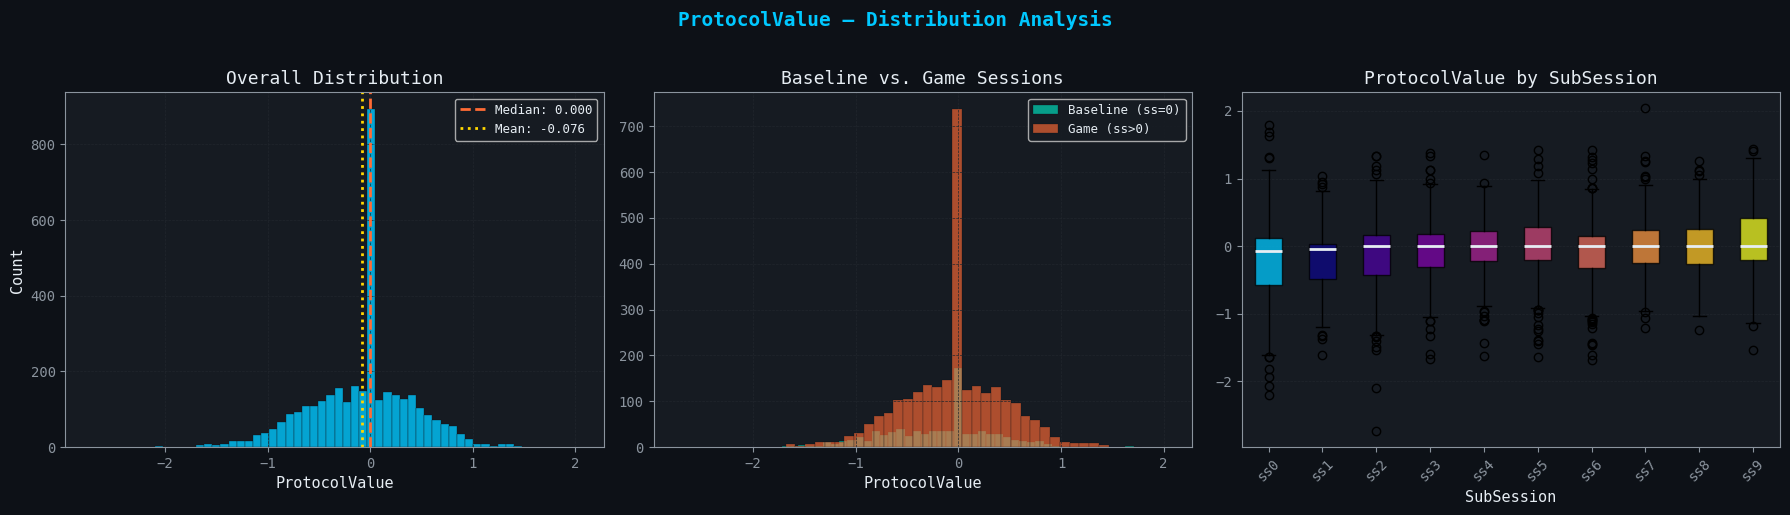

💾 Saved: ../outputs/figures/eda_protocolvalue_distribution.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ProtocolValue - Distribution Analysis', fontsize=14,
             color=NEROES_PALETTE['cyan'], fontweight='bold', y=1.02)

# ── Distribution overall ──────────────────────────────────────────────────────
axes[0].hist(pv.dropna(), bins=60, color=NEROES_PALETTE['cyan'], alpha=0.8,
             edgecolor=NEROES_PALETTE['bg'], linewidth=0.3)
axes[0].axvline(pv.median(), color=NEROES_PALETTE['orange'], lw=2,
                linestyle='--', label=f'Median: {pv.median():.3f}')
axes[0].axvline(pv.mean(), color=NEROES_PALETTE['yellow'], lw=2,
                linestyle=':', label=f'Mean: {pv.mean():.3f}')
axes[0].set_xlabel('ProtocolValue')
axes[0].set_ylabel('Count')
axes[0].set_title('Overall Distribution')
axes[0].legend(fontsize=9)
axes[0].grid(True)

# ── Distribution by subsession type ──────────────────────────────────────────
df_all['session_type'] = df_all['subsession'].apply(
    lambda x: 'Baseline (ss=0)' if x == 0 else 'Game (ss>0)'
)
for label, color in zip(['Baseline (ss=0)', 'Game (ss>0)'],
                         [NEROES_PALETTE['teal'], NEROES_PALETTE['orange']]):
    subset = df_all[df_all['session_type'] == label][TARGET].dropna()
    axes[1].hist(subset, bins=50, alpha=0.65, color=color,
                 edgecolor=NEROES_PALETTE['bg'], linewidth=0.3, label=label)
axes[1].set_xlabel('ProtocolValue')
axes[1].set_title('Baseline vs. Game Sessions')
axes[1].legend(fontsize=9)
axes[1].grid(True)

# ── Box plot per subsession ───────────────────────────────────────────────────
data_by_ss = [df_all[df_all['subsession'] == i][TARGET].dropna().values
              for i in range(10)]
bp = axes[2].boxplot(data_by_ss, patch_artist=True, notch=False,
                      medianprops=dict(color=NEROES_PALETTE['white'], lw=2))
for i, patch in enumerate(bp['boxes']):
    c = NEROES_PALETTE['cyan'] if i == 0 else plt.cm.plasma((i - 1) / 8)
    patch.set_facecolor(c)
    patch.set_alpha(0.75)
axes[2].set_xticklabels([f'ss{i}' for i in range(10)], rotation=45)
axes[2].set_xlabel('SubSession')
axes[2].set_title('ProtocolValue by SubSession')
axes[2].grid(True, axis='y')

plt.tight_layout()
plt.savefig('../outputs/figures/eda_protocolvalue_distribution.png', dpi=150,
            bbox_inches='tight', facecolor=NEROES_PALETTE['bg'])
plt.show()
print('💾 Saved: ../outputs/figures/eda_protocolvalue_distribution.png')

## 7. Temporal Dynamics of `ProtocolValue`

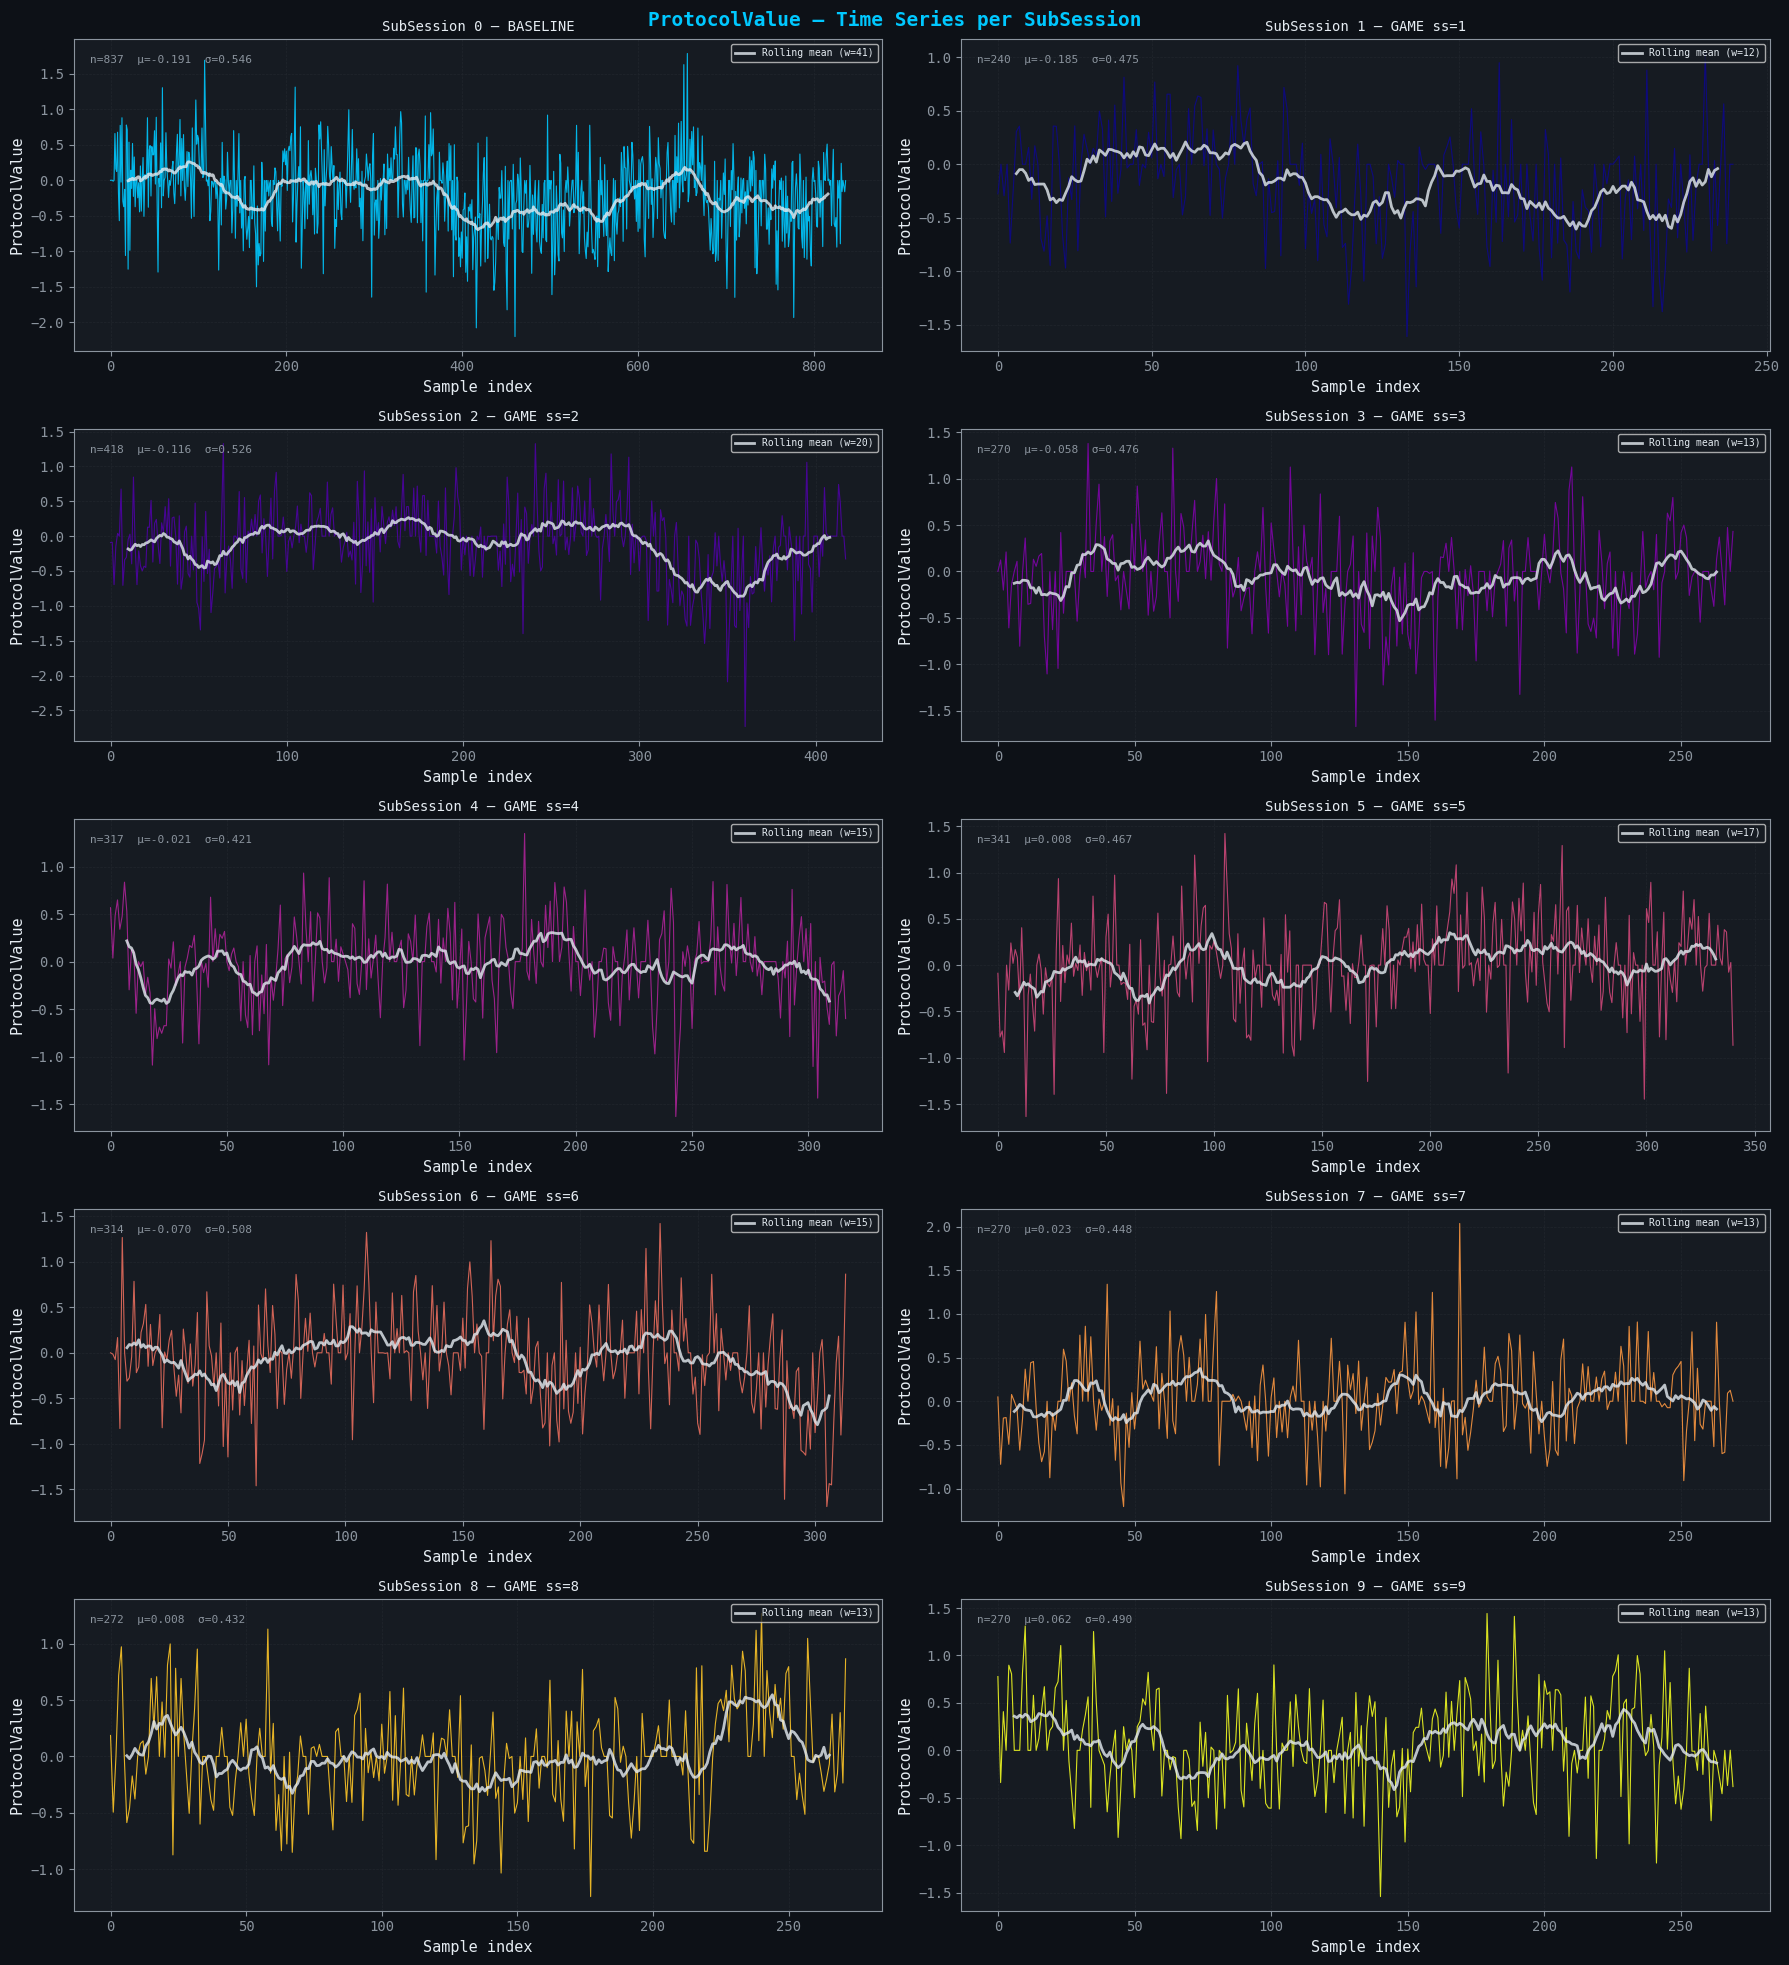

💾 Saved: ../outputs/figures/eda_protocolvalue_timeseries.png


In [ ]:
# ── Add a within-subsession sample index ────────────────────────────────────
df_all['sample_idx'] = df_all.groupby('subsession').cumcount()

fig, axes = plt.subplots(5, 2, figsize=(18, 20))
fig.suptitle('ProtocolValue - Time Series per SubSession', fontsize=14,
             color=NEROES_PALETTE['cyan'], fontweight='bold')
axes = axes.flatten()

for i in range(10):
    ss_df = df_all[df_all['subsession'] == i].copy()
    color = NEROES_PALETTE['cyan'] if i == 0 else plt.cm.plasma((i - 1) / 8)

    axes[i].plot(ss_df['sample_idx'], ss_df[TARGET],
                 color=color, lw=0.8, alpha=0.9)

    # ── Rolling mean ────────────────────────────────────────────────────────
    window = max(10, len(ss_df) // 20)
    roll = ss_df[TARGET].rolling(window, center=True).mean()
    axes[i].plot(ss_df['sample_idx'], roll,
                 color=NEROES_PALETTE['white'], lw=2.0, alpha=0.8,
                 label=f'Rolling mean (w={window})')

    label = 'BASELINE' if i == 0 else f'GAME ss={i}'
    axes[i].set_title(f'SubSession {i} - {label}', fontsize=10)
    axes[i].set_xlabel('Sample index')
    axes[i].set_ylabel('ProtocolValue')
    axes[i].legend(fontsize=7, loc='upper right')
    axes[i].grid(True)
    axes[i].text(0.02, 0.95,
                 f'n={len(ss_df):,}  μ={ss_df[TARGET].mean():.3f}  σ={ss_df[TARGET].std():.3f}',
                 transform=axes[i].transAxes, fontsize=8,
                 color=NEROES_PALETTE['muted'], va='top')

plt.tight_layout()
plt.savefig('../outputs/figures/eda_protocolvalue_timeseries.png', dpi=150,
            bbox_inches='tight', facecolor=NEROES_PALETTE['bg'])
plt.show()
print('💾 Saved: ../outputs/figures/eda_protocolvalue_timeseries.png')

## 8. Behavioural Signal - `PlayerPositionY`

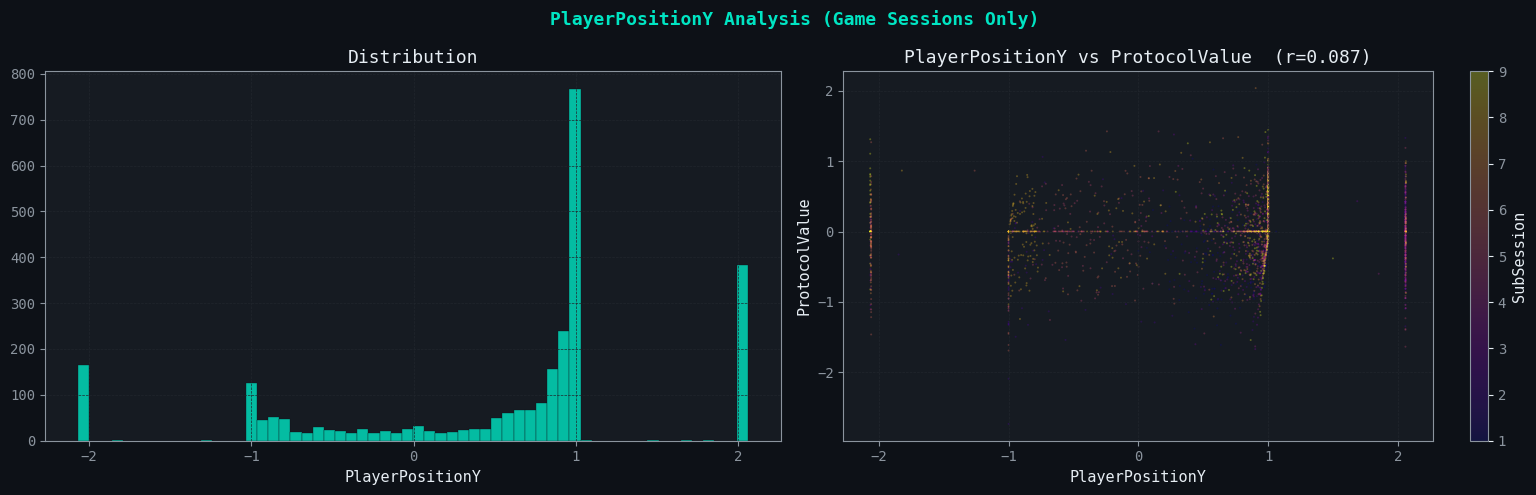

💾 Saved: ../outputs/figures/eda_playerpositionY.png

Correlation (PlayerPositionY, ProtocolValue): 0.0870
PlayerPositionY stats (game sessions):
count    2712.0000
mean        0.5499
std         1.0579
min        -2.0661
25%         0.0213
50%         0.9040
75%         1.0000
max         2.0609


In [13]:
# ── PlayerPositionY only exists in game subsessions ───────────────────────────
PPY_COL = 'PlayerPositionY'  # update if column name differs

if PPY_COL not in df_all.columns:
    pos_candidates = [c for c in df_all.columns
                      if any(kw in c.lower() for kw in ['player', 'position', 'pos', 'y'])]
    print(f'⚠️  {PPY_COL} not found. Candidates: {pos_candidates}')
else:
    game_df = df_all[df_all['subsession'] > 0].copy()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('PlayerPositionY Analysis (Game Sessions Only)',
                 fontsize=13, color=NEROES_PALETTE['teal'], fontweight='bold')

    # ── Distribution ────────────────────────────────────────────────────────
    axes[0].hist(game_df[PPY_COL].dropna(), bins=60,
                 color=NEROES_PALETTE['teal'], alpha=0.8,
                 edgecolor=NEROES_PALETTE['bg'], linewidth=0.3)
    axes[0].set_xlabel(PPY_COL)
    axes[0].set_title('Distribution')
    axes[0].grid(True)

    # ── Scatter vs ProtocolValue ──────────────────────────────────────────────
    sc = axes[1].scatter(
        game_df[PPY_COL], game_df[TARGET],
        c=game_df['subsession'], cmap='plasma',
        alpha=0.3, s=2, edgecolors='none'
    )
    cb = fig.colorbar(sc, ax=axes[1])
    cb.set_label('SubSession', color=NEROES_PALETTE['white'])
    cb.ax.yaxis.set_tick_params(color=NEROES_PALETTE['white'])

    corr = game_df[[PPY_COL, TARGET]].corr().iloc[0, 1]
    axes[1].set_xlabel(PPY_COL)
    axes[1].set_ylabel(TARGET)
    axes[1].set_title(f'PlayerPositionY vs ProtocolValue  (r={corr:.3f})')
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig('../outputs/figures/eda_playerpositionY.png', dpi=150,
                bbox_inches='tight', facecolor=NEROES_PALETTE['bg'])
    plt.show()
    print('💾 Saved: ../outputs/figures/eda_playerpositionY.png')

    print(f'\nCorrelation (PlayerPositionY, ProtocolValue): {corr:.4f}')
    print(f'PlayerPositionY stats (game sessions):')
    print(game_df[PPY_COL].describe().round(4).to_string())

## 9. Signal Feature Identification

In [ ]:
# ── Identify physiological vs. game vs. metadata columns ─────────────────────
all_cols_list = [c for c in df_all.columns if c not in ('subsession', 'session_type', 'sample_idx')]

# Heuristic categorisation - will be reviewed manually
game_keywords     = ['player', 'position', 'score', 'level', 'speed', 'health']
time_keywords     = ['time', 'timestamp', 'ts', 'tick', 'frame', 'elapsed']
eeg_keywords      = ['alpha', 'beta', 'theta', 'delta', 'gamma', 'eeg', 'band',
                     'power', 'freq', 'spectral']
physio_keywords   = ['hr', 'hrv', 'gsr', 'eda', 'bvp', 'spo2', 'ppg',
                     'respir', 'temp', 'skin', 'ecg']

def categorise(col):
    c = col.lower()
    if any(k in c for k in time_keywords):    return 'temporal'
    if any(k in c for k in eeg_keywords):     return 'EEG'
    if any(k in c for k in physio_keywords):  return 'physiological'
    if any(k in c for k in game_keywords):    return 'game'
    if col == TARGET:                         return 'TARGET'
    return 'unknown'

col_categories = {col: categorise(col) for col in all_cols_list}

cat_df = pd.DataFrame.from_dict(col_categories, orient='index', columns=['category'])
cat_df.index.name = 'column'
print('Column categorisation (heuristic - review and correct):')
display(cat_df.groupby('category').apply(lambda x: list(x.index)).rename('columns'))
print()
display(cat_df.reset_index())

Column categorisation (heuristic — review and correct):


category
EEG         [AF3Alpha, AF3Gamma, AF3HighBeta, AF3LowBeta, ...
TARGET                                        [ProtocolValue]
game        [AsteroidPositionX, AsteroidPositionY, LevelPr...
temporal                                          [Timestamp]
unknown     [AF3SignalQuality, AF4SignalQuality, Annotatio...
Name: columns, dtype: object

,column,category
0,AF3Alpha,EEG
1,AF3Gamma,EEG
2,AF3HighBeta,EEG
3,AF3LowBeta,EEG
4,AF3SignalQuality,unknown
...,...,...
144,TangentCoefficient,unknown
145,Timestamp,temporal
146,Training,unknown
147,TranslationCoefficient,unknown


## 10. Correlation Heatmap - All Numeric Features

In [15]:
numeric_cols = df_all.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ('subsession', 'sample_idx')]

corr_matrix = df_all[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(max(10, len(numeric_cols)), max(8, len(numeric_cols) * 0.8)))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=len(numeric_cols) <= 20,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    linewidths=0.3,
    cbar_kws={'label': 'Pearson r'},
    annot_kws={'size': 7},
)
ax.set_title('Feature Correlation Matrix', color=NEROES_PALETTE['cyan'],
             fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/figures/eda_correlation_heatmap.png', dpi=150,
            bbox_inches='tight', facecolor=NEROES_PALETTE['bg'])
plt.show()
print('💾 Saved: ../outputs/figures/eda_correlation_heatmap.png')

# ── Top correlates with ProtocolValue ────────────────────────────────────────
if TARGET in corr_matrix.columns:
    top_corr = corr_matrix[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
    print(f'\nTop correlations with {TARGET}:')
    print(top_corr.head(15).round(4).to_string())

💾 Saved: ../outputs/figures/eda_correlation_heatmap.png

Top correlations with ProtocolValue:
TranslationCoefficient   -0.1282
MiddlePercentile          0.1282
Percentile                0.1282
MaxPercentile             0.1282
TangentCoefficient        0.1282
MinPercentile             0.1282
PlayerPositionY           0.1133
LevelProgress             0.0852
PlayerPositionX          -0.0841
Morale                    0.0593
MaxBaseline               0.0489
MinBaseline              -0.0400
PzSignalQuality          -0.0202
C3SignalQuality          -0.0198
C4SignalQuality          -0.0151


## 11. Baseline vs. Game Session - Signal Level Comparison

In [ ]:
from scipy import stats

baseline_df = df_all[df_all['subsession'] == 0]
game_df     = df_all[df_all['subsession'] > 0]

results = []
for col in numeric_cols:
    b = baseline_df[col].dropna()
    g = game_df[col].dropna()
    if len(b) < 5 or len(g) < 5:
        continue
    tstat, pval = stats.mannwhitneyu(b, g, alternative='two-sided')
    results.append({
        'feature':        col,
        'baseline_mean':  b.mean(),
        'game_mean':      g.mean(),
        'delta_mean':     g.mean() - b.mean(),
        'baseline_std':   b.std(),
        'game_std':       g.std(),
        'p_value':        pval,
        'significant':    pval < 0.05,
    })

results_df = pd.DataFrame(results).sort_values('p_value')
print('Baseline vs. Game - Mann-Whitney U test:')
display(results_df.round(5))

Baseline vs. Game — Mann-Whitney U test:


,feature,baseline_mean,game_mean,delta_mean,baseline_std,game_std,p_value,significant
75,MaxPercentile,0.0,0.54000,0.54000,0.0,0.00000,0.0,True
79,MinPercentile,0.0,0.42000,0.42000,0.0,0.00000,0.0,True
111,Percentile,0.0,0.49000,0.49000,0.0,0.00000,0.0,True
80,Morale,0.0,0.84130,0.84130,0.0,0.28827,0.0,True
78,MinBaseline,0.0,-0.17113,-0.17113,0.0,0.08708,0.0,True
...,...,...,...,...,...,...,...,...
129,T8Gamma,0.0,0.00000,0.00000,0.0,0.00000,1.0,False
131,T8LowBeta,0.0,0.00000,0.00000,0.0,0.00000,1.0,False
130,T8HighBeta,0.0,0.00000,0.00000,0.0,0.00000,1.0,False
133,T8Theta,0.0,0.00000,0.00000,0.0,0.00000,1.0,False


## 12. Temporal Autocorrelation of `ProtocolValue`

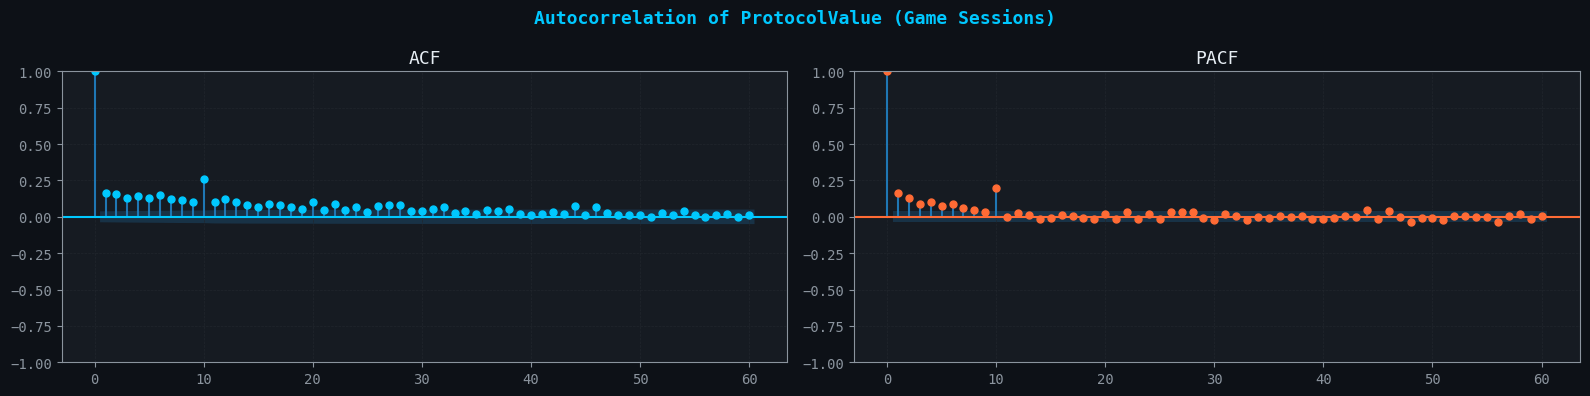

💾 Saved: ../outputs/figures/eda_autocorrelation.png

📌 Interpretation:
  - Significant ACF lags → ProtocolValue has temporal memory → lag features are valuable
  - PACF cut-off at lag k → AR(k) structure → useful for prediction horizon choice


In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Use game subsessions concatenated
game_pv = df_all[df_all['subsession'] > 0][TARGET].dropna().reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle(f'Autocorrelation of {TARGET} (Game Sessions)',
             fontsize=13, color=NEROES_PALETTE['cyan'], fontweight='bold')

plot_acf(game_pv, lags=60, ax=axes[0],
         color=NEROES_PALETTE['cyan'],
         title='ACF')
plot_pacf(game_pv, lags=60, ax=axes[1], method='ywm',
          color=NEROES_PALETTE['orange'],
          title='PACF')

for ax in axes:
    ax.set_facecolor(NEROES_PALETTE['surface'])
    ax.grid(True)

plt.tight_layout()
plt.savefig('../outputs/figures/eda_autocorrelation.png', dpi=150,
            bbox_inches='tight', facecolor=NEROES_PALETTE['bg'])
plt.show()
print('💾 Saved: ../outputs/figures/eda_autocorrelation.png')
print('\n📌 Interpretation:')
print('  - Significant ACF lags → ProtocolValue has temporal memory → lag features are valuable')
print('  - PACF cut-off at lag k → AR(k) structure → useful for prediction horizon choice')

## 13. Delta Analysis - ProtocolValue Change

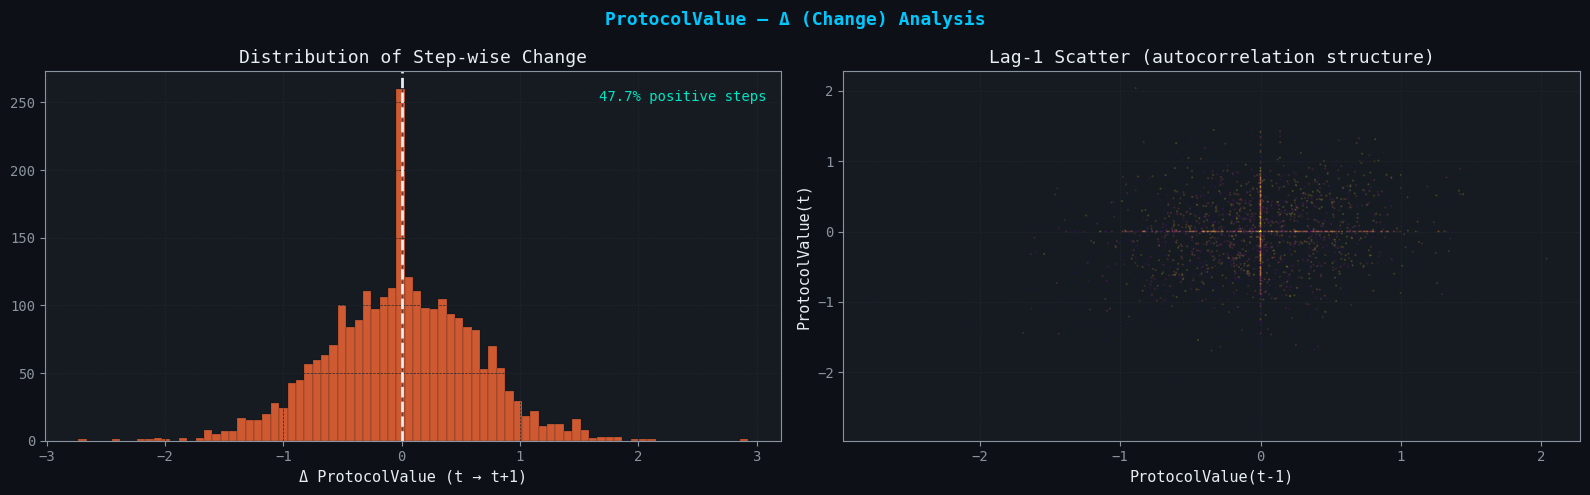

💾 Saved: ../outputs/figures/eda_delta_analysis.png


In [ ]:
# ── Compute delta(ProtocolValue) within each subsession ──────────────────────
df_all = df_all.sort_values(['subsession', 'sample_idx'])
df_all['pv_delta']   = df_all.groupby('subsession')[TARGET].diff(1)
df_all['pv_delta_2'] = df_all.groupby('subsession')[TARGET].diff(2)
df_all['pv_lag1']    = df_all.groupby('subsession')[TARGET].shift(1)
df_all['pv_lag2']    = df_all.groupby('subsession')[TARGET].shift(2)
df_all['pv_lag5']    = df_all.groupby('subsession')[TARGET].shift(5)

game_df = df_all[df_all['subsession'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('ProtocolValue - Δ (Change) Analysis',
             fontsize=13, color=NEROES_PALETTE['cyan'], fontweight='bold')

axes[0].hist(game_df['pv_delta'].dropna(), bins=80,
             color=NEROES_PALETTE['orange'], alpha=0.8,
             edgecolor=NEROES_PALETTE['bg'], linewidth=0.2)
axes[0].axvline(0, color=NEROES_PALETTE['white'], lw=2, linestyle='--')
axes[0].set_xlabel('Δ ProtocolValue (t → t+1)')
axes[0].set_title('Distribution of Step-wise Change')
axes[0].grid(True)
pos_frac = (game_df['pv_delta'].dropna() > 0).mean()
axes[0].text(0.98, 0.95, f'{pos_frac:.1%} positive steps',
             transform=axes[0].transAxes, ha='right', va='top',
             color=NEROES_PALETTE['teal'], fontsize=10)

axes[1].scatter(game_df['pv_lag1'], game_df[TARGET],
                c=game_df['subsession'], cmap='plasma',
                alpha=0.2, s=2, edgecolors='none')
axes[1].set_xlabel('ProtocolValue(t-1)')
axes[1].set_ylabel('ProtocolValue(t)')
axes[1].set_title('Lag-1 Scatter (autocorrelation structure)')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../outputs/figures/eda_delta_analysis.png', dpi=150,
            bbox_inches='tight', facecolor=NEROES_PALETTE['bg'])
plt.show()
print('💾 Saved: ../outputs/figures/eda_delta_analysis.png')

## 14. ProtocolValue Trajectory - Across Game SubSessions

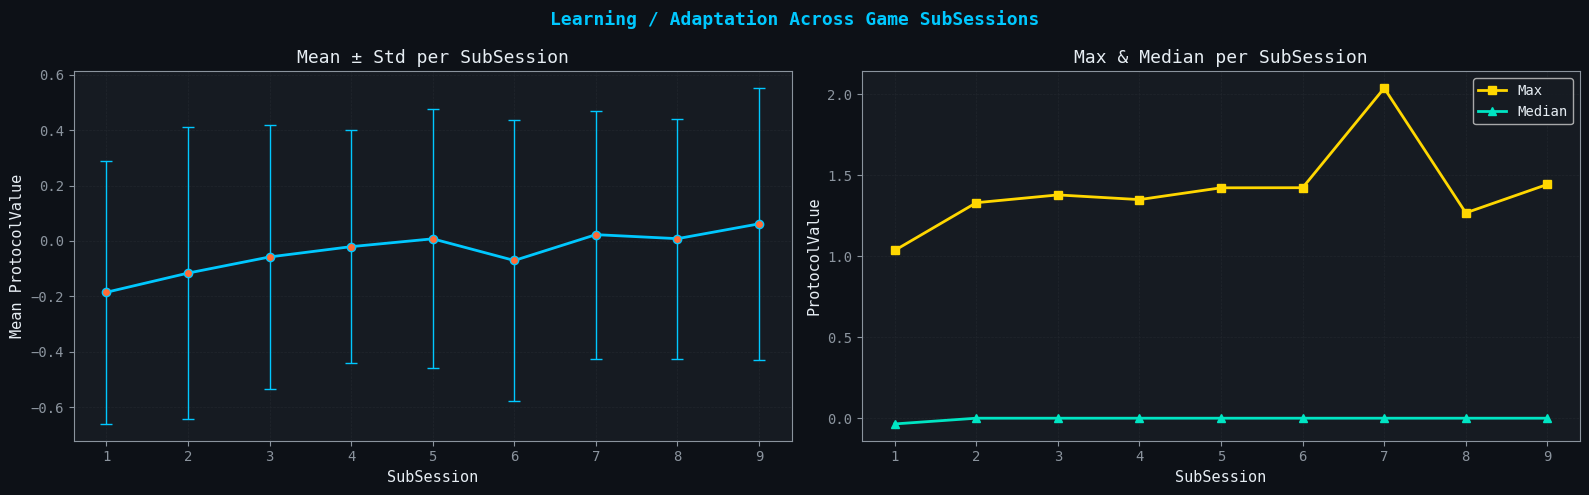

💾 Saved: ../outputs/figures/eda_subsession_trajectory.png

📌 Interpretation:
  - Rising trend → neurofeedback is working, system can reinforce
  - Flat / noisy → adaptation signal is weak, harder prediction task
  - Non-monotonic → complex dynamics, context-dependent actions needed


In [19]:
# ── Does the user improve across subsessions? ─────────────────────────────────
ss_stats = df_all[df_all['subsession'] > 0].groupby('subsession')[TARGET].agg(
    ['mean', 'std', 'median', 'max']
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Learning / Adaptation Across Game SubSessions',
             fontsize=13, color=NEROES_PALETTE['cyan'], fontweight='bold')

axes[0].errorbar(ss_stats['subsession'], ss_stats['mean'], yerr=ss_stats['std'],
                 color=NEROES_PALETTE['cyan'], lw=2, marker='o',
                 capsize=4, elinewidth=1, markerfacecolor=NEROES_PALETTE['orange'])
axes[0].set_xlabel('SubSession')
axes[0].set_ylabel('Mean ProtocolValue')
axes[0].set_title('Mean ± Std per SubSession')
axes[0].grid(True)

axes[1].plot(ss_stats['subsession'], ss_stats['max'],
             color=NEROES_PALETTE['yellow'], lw=2, marker='s', label='Max')
axes[1].plot(ss_stats['subsession'], ss_stats['median'],
             color=NEROES_PALETTE['teal'], lw=2, marker='^', label='Median')
axes[1].set_xlabel('SubSession')
axes[1].set_ylabel('ProtocolValue')
axes[1].set_title('Max & Median per SubSession')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../outputs/figures/eda_subsession_trajectory.png', dpi=150,
            bbox_inches='tight', facecolor=NEROES_PALETTE['bg'])
plt.show()
print('💾 Saved: ../outputs/figures/eda_subsession_trajectory.png')
print()
print('📌 Interpretation:')
print('  - Rising trend → neurofeedback is working, system can reinforce')
print('  - Flat / noisy → adaptation signal is weak, harder prediction task')
print('  - Non-monotonic → complex dynamics, context-dependent actions needed')

## 15. Missing Data & Data Quality Report

In [20]:
print('═' * 60)
print('  DATA QUALITY REPORT')
print('═' * 60)

quality = pd.DataFrame({
    'total':      df_all.shape[0],
    'non_null':   df_all.notna().sum(),
    'null_count': df_all.isna().sum(),
    'null_%':     (df_all.isna().mean() * 100).round(2),
    'unique':     df_all.nunique(),
    'dtype':      df_all.dtypes,
})
display(quality)

# ── Duplicate rows ────────────────────────────────────────────────────────────
n_dups = df_all.duplicated().sum()
print(f'\nDuplicate rows: {n_dups} ({n_dups / len(df_all):.2%})')

# ── Outlier detection via IQR ─────────────────────────────────────────────────
print('\nOutlier summary (IQR method, factor=3):')
for col in numeric_cols[:10]:  # first 10 to keep output readable
    q1, q3 = df_all[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df_all[col] < q1 - 3 * iqr) | (df_all[col] > q3 + 3 * iqr)).sum()
    if n_out > 0:
        print(f'  {col}: {n_out} outliers ({n_out / len(df_all):.2%})')

════════════════════════════════════════════════════════════
  DATA QUALITY REPORT
════════════════════════════════════════════════════════════


,total,non_null,null_count,null_%,unique,dtype
AF3Alpha,3549,3549,0,0.00,1,int64
AF3Gamma,3549,3549,0,0.00,1,int64
AF3HighBeta,3549,3549,0,0.00,1,int64
AF3LowBeta,3549,3549,0,0.00,1,int64
AF3SignalQuality,3549,3549,0,0.00,1,int64
...,...,...,...,...,...,...
pv_delta,3549,3539,10,0.28,3354,float64
pv_delta_2,3549,3529,20,0.56,3369,float64
pv_lag1,3549,3539,10,0.28,2810,float64
pv_lag2,3549,3529,20,0.56,2803,float64



Duplicate rows: 0 (0.00%)

Outlier summary (IQR method, factor=3):


## 16. Action Space Exploration

In [ ]:
# ── What could the "action" be in this system? ────────────────────────────────
# In a neurofeedback game:
# - The system adjusts a difficulty/threshold parameter
# - Or recommends a different protocol parameter
# We need to identify candidate action columns

action_keywords = ['threshold', 'difficulty', 'param', 'target', 'feedback',
                   'gain', 'reward', 'level', 'protocol', 'action', 'input',
                   'set', 'control']
action_candidates = [
    c for c in df_all.columns
    if any(kw in c.lower() for kw in action_keywords)
    and c not in (TARGET, 'subsession', 'session_type', 'sample_idx')
]

print('Candidate action/control columns:')
if action_candidates:
    for col in action_candidates:
        print(f'  {col}: unique values = {df_all[col].nunique()}, '
              f'range = [{df_all[col].min():.4f}, {df_all[col].max():.4f}]')
else:
    print('  ⚠️  None found automatically - ACTION SPACE NEEDS MANUAL IDENTIFICATION')
    print('  → Review the full column list below and identify what parameter the system controls:')
    print()
    for c in df_all.columns:
        if c not in ('subsession', 'session_type', 'sample_idx', 'pv_delta',
                     'pv_delta_2', 'pv_lag1', 'pv_lag2', 'pv_lag5'):
            print(f'    {c}: dtype={df_all[c].dtype}, unique={df_all[c].nunique()}')

Candidate action/control columns:
  LevelProgress: unique values = 2, range = [0.0000, 0.5000]
  RecoveryOffsetFromBaseline: unique values = 0, range = [nan, nan]


## 17. EDA Summary & Modelling Implications

In [ ]:
summary = f"""
╔══════════════════════════════════════════════════════════════════════════╗
║              EDA SUMMARY - NEROES NEUROFEEDBACK CHALLENGE                ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  DATA STRUCTURE                                                          ║
║  ─────────────                                                           ║
║  • Total rows     : {len(df_all):,}                                           
║  • SubSessions    : 0 (baseline) + 1-9 (game)                           ║
║  • Columns        : {len(df_all.columns)}                                              
║                                                                          ║
║  TARGET (ProtocolValue)                                                  ║
║  ──────────────────────                                                  ║
║  • Overall mean   : {df_all[TARGET].mean():.4f}                                    
║  • Overall std    : {df_all[TARGET].std():.4f}                                    
║  • Baseline mean  : {df_all[df_all['subsession']==0][TARGET].mean():.4f}                                    
║  • Game mean      : {df_all[df_all['subsession']>0][TARGET].mean():.4f}                                    
║                                                                          ║
║  MODELLING IMPLICATIONS                                                  ║
║  ──────────────────────                                                  ║
║  1. Subsession 0 provides a personalised baseline signal - use it       ║
║     to normalise features (z-score relative to baseline)                ║
║  2. Lag features (t-1, t-2, t-5) likely informative → AR structure      ║
║  3. Delta(ProtocolValue) as reward signal for RL                        ║
║  4. Action space TBD - needs clarification with Neroes team              ║
║  5. Cross-subsession trend → can use subsession index as context        ║
║                                                                          ║
║  NEXT STEPS                                                              ║
║  ──────────                                                              ║
║  → 02_features.ipynb  : Build feature matrix with lags + rolling stats  ║
║  → 03_prediction.ipynb: Supervised model for ProtocolValue(t+1)         ║
║  → 04_rl.ipynb        : RL agent (contextual bandit / Q-learning)       ║
║  → 05_comparison.ipynb: Baseline comparison & evaluation                ║
║                                                                          ║
╚══════════════════════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════════════════════╗
║              EDA SUMMARY — NEROES NEUROFEEDBACK CHALLENGE                ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  DATA STRUCTURE                                                          ║
║  ─────────────                                                           ║
║  • Total rows     : 3,549                                           
║  • SubSessions    : 0 (baseline) + 1-9 (game)                           ║
║  • Columns        : 157                                              
║                                                                          ║
║  TARGET (ProtocolValue)                                                  ║
║  ──────────────────────                                                  ║
║  • Overall mean   : -0.0760                                    
║  • Overall std    :

In [23]:
# ── Save the processed combined dataframe for downstream notebooks ────────────
out_path = Path('../data/processed/processed_data.parquet')
df_all.to_parquet(out_path, index=False)
print(f'💾 Processed data saved to: {out_path}')
print(f'   Shape: {df_all.shape}')
print(f'   Columns: {list(df_all.columns)}')

💾 Processed data saved to: ../data/processed/processed_data.parquet
   Shape: (3549, 157)
   Columns: ['AF3Alpha', 'AF3Gamma', 'AF3HighBeta', 'AF3LowBeta', 'AF3SignalQuality', 'AF3Theta', 'AF4Alpha', 'AF4Gamma', 'AF4HighBeta', 'AF4LowBeta', 'AF4SignalQuality', 'AF4Theta', 'Annotations', 'AsteroidPositionX', 'AsteroidPositionY', 'AudioTracks', 'Baseline', 'C3Alpha', 'C3Gamma', 'C3HighBeta', 'C3LowBeta', 'C3SignalQuality', 'C3Theta', 'C4Alpha', 'C4Gamma', 'C4HighBeta', 'C4LowBeta', 'C4SignalQuality', 'C4Theta', 'F3Alpha', 'F3Gamma', 'F3HighBeta', 'F3LowBeta', 'F3SignalQuality', 'F3Theta', 'F4Alpha', 'F4Gamma', 'F4HighBeta', 'F4LowBeta', 'F4SignalQuality', 'F4Theta', 'F7Alpha', 'F7Gamma', 'F7HighBeta', 'F7LowBeta', 'F7SignalQuality', 'F7Theta', 'F8Alpha', 'F8Gamma', 'F8HighBeta', 'F8LowBeta', 'F8SignalQuality', 'F8Theta', 'FC5Alpha', 'FC5Gamma', 'FC5HighBeta', 'FC5LowBeta', 'FC5SignalQuality', 'FC5Theta', 'FC6Alpha', 'FC6Gamma', 'FC6HighBeta', 'FC6LowBeta', 'FC6SignalQuality', 'FC6Theta',